In [4]:
import pandas as pd
import numpy as np

In [5]:
# Load dataset
df = pd.read_csv("/content/Titanic-Dataset.csv")

In [6]:
len(df)

891

In [7]:
# Missing values analysis
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum()/len(df))*100

print(missing_count.sort_values(ascending=False).head(10))
print(missing_percent.sort_values(ascending=False).head(10))

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
dtype: int64
Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
dtype: float64


In [8]:
# Simple imputation
df_mean = df.fillna(df.mean(numeric_only=True))
df_median = df.fillna(df.median(numeric_only=True))
df_mode = df.fillna(df.mode().iloc[0])

In [9]:
# Forward fill
df_ffill = df.fillna(method='ffill')

/tmp/ipykernel_1318/2861128085.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ffill = df.fillna(method='ffill')


In [10]:
df_ffill=df.ffill()

In [11]:
# KNN Imputation
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
df_knn = pd.DataFrame(imputer.fit_transform(df.select_dtypes(include=np.number)))


In [12]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [13]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression


import missingno as msno

In [14]:
# ================================
# 2. LOAD DATA
# ================================
df = pd.read_csv("/content/Titanic-Dataset.csv")   # change path accordingly

print("Shape:", df.shape)
print(df.head())

Shape: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   

In [15]:
# ================================
# 3. MISSING VALUE IDENTIFICATION
# ================================

# 1. Count missing values
missing_count = df.isnull().sum()
print("\nMissing Count:\n", missing_count.sort_values(ascending=False))


Missing Count:
 Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64


In [16]:

# 2. Percentage missing
missing_percent = (df.isnull().sum() / len(df)) * 100
print("\nMissing Percentage:\n", missing_percent.sort_values(ascending=False))


Missing Percentage:
 Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64


In [17]:
# 3. Columns with missing values
missing_cols = df.columns[df.isnull().any()]
print("\nColumns with Missing Values:\n", missing_cols)


Columns with Missing Values:
 Index(['Age', 'Cabin', 'Embarked'], dtype='object')


In [18]:
# 4. Row-wise missing count
df['missing_per_row'] = df.isnull().sum(axis=1)

In [19]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,missing_per_row
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,2
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,0
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,1
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,1
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,1


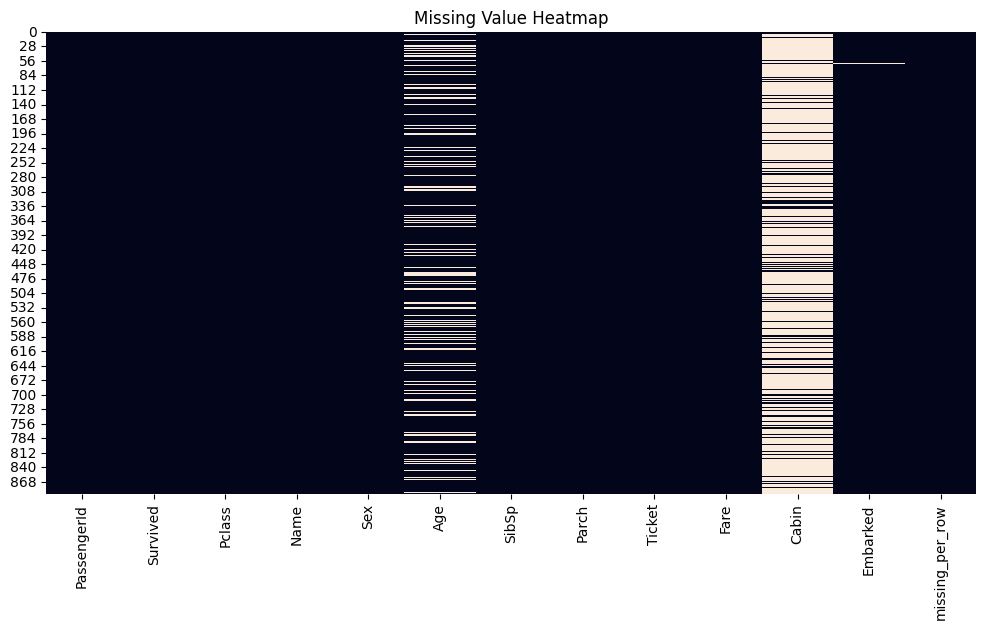

In [20]:

# 5. Heatmap of missing values
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

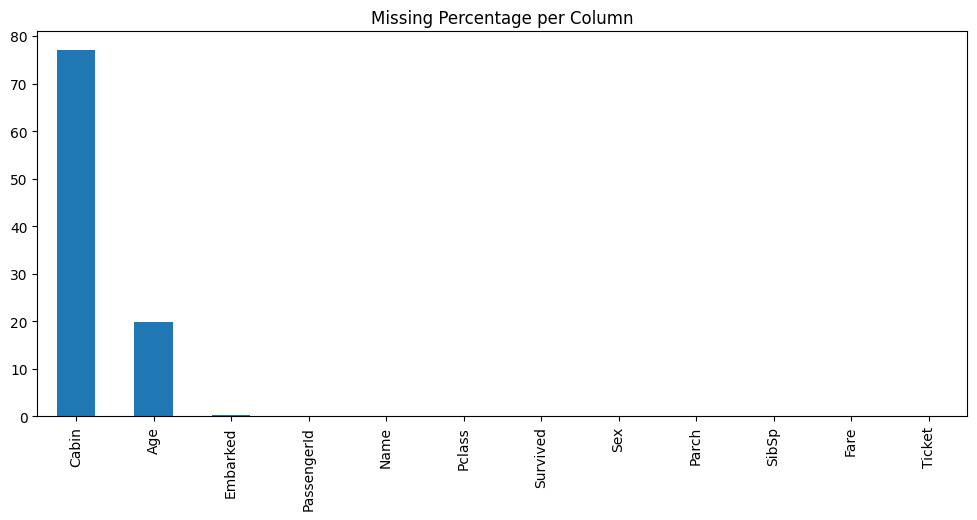

In [21]:
# 6. Bar plot of missing percentage
missing_percent.sort_values(ascending=False).plot(kind='bar', figsize=(12,5))
plt.title("Missing Percentage per Column")
plt.show()

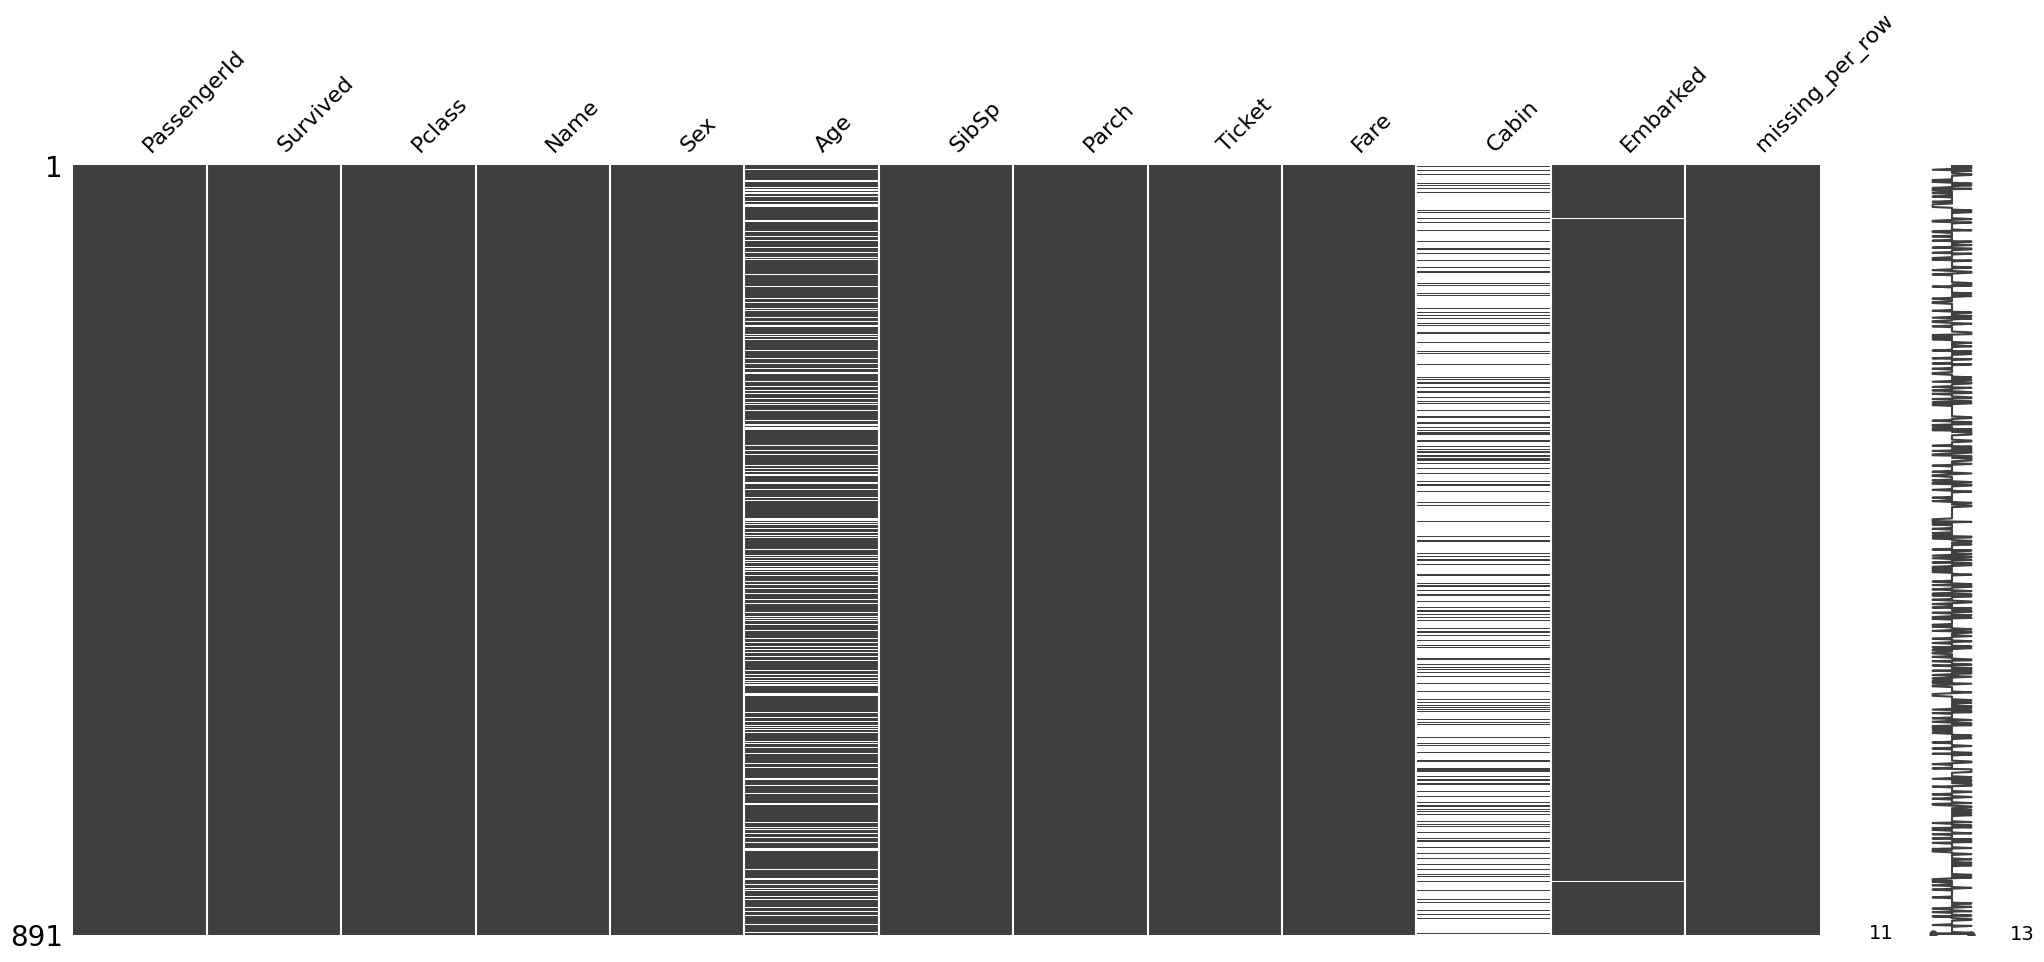

In [22]:
# 7. Missingno matrix plot
msno.matrix(df)
plt.show()

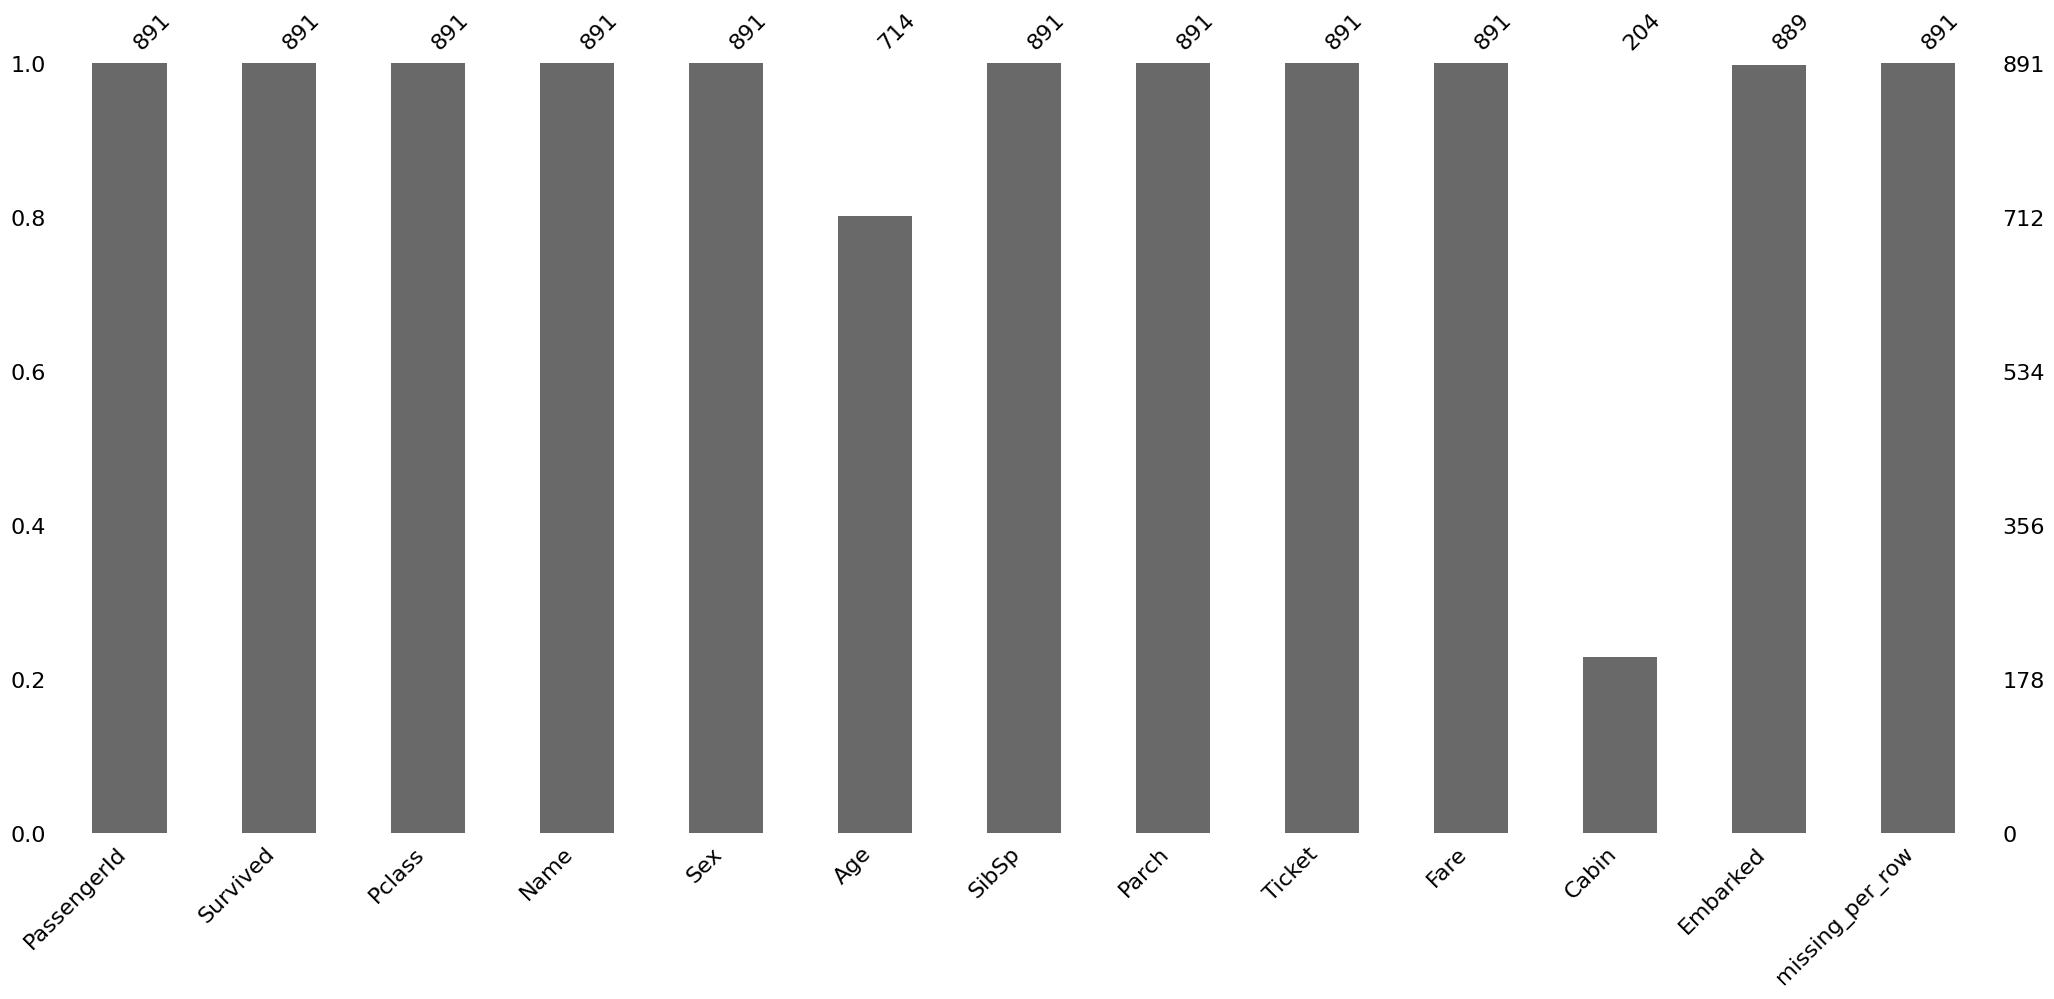

In [23]:

# 8. Missingno bar plot
msno.bar(df)
plt.show()

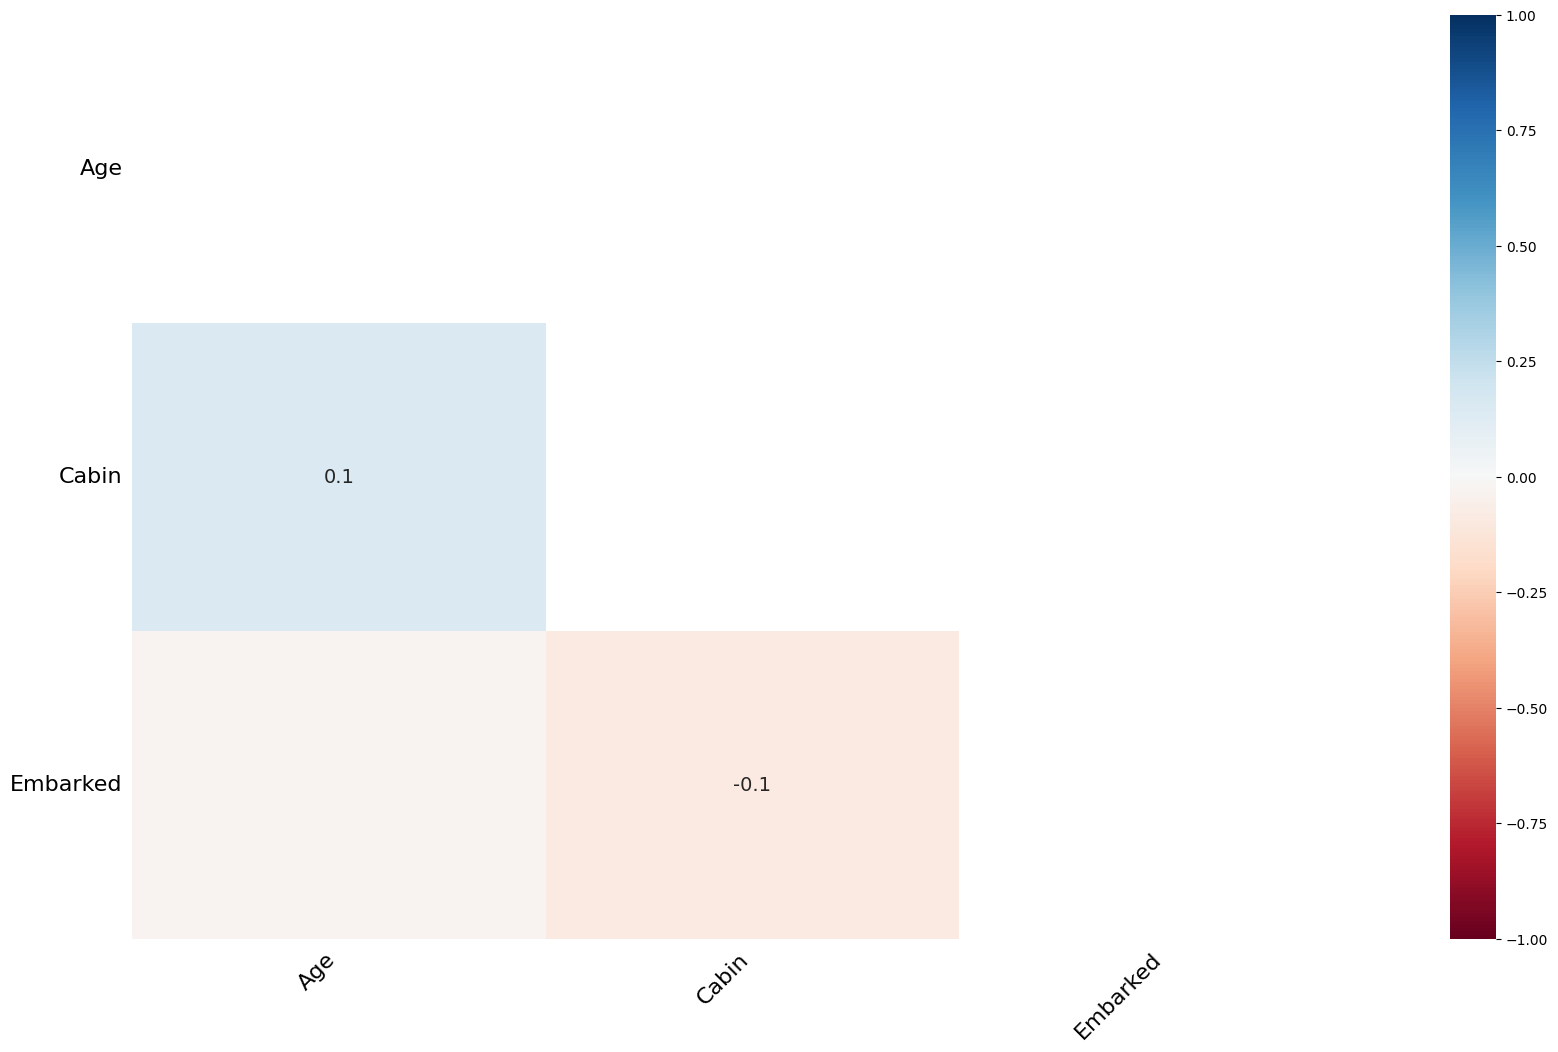

In [24]:
msno.heatmap(df)
plt.show()

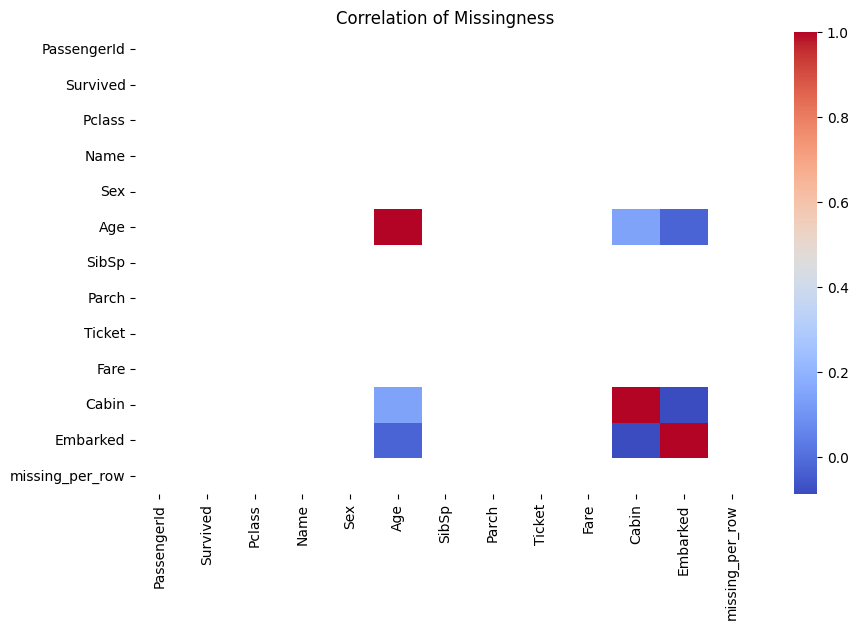

In [25]:
#10.Check correlation of missingness
missing_corr=df.isnull().corr()
plt.figure(figsize=(10,6))
sns.heatmap(missing_corr,cmap='coolwarm')
plt.title("Correlation of Missingness")
plt.show()

In [26]:
# ================================
# 4. UNDERSTANDING MISSINGNESS
# ================================

# Example: Check relation with target variable
if 'SalePrice' in df.columns:
    print("\nMissing vs Target Analysis:")
    print(df.groupby(df['LotFrontage'].isnull())['SalePrice'].mean())

In [27]:
# ================================
# 5. DROPPING METHODS (if needed)
# ================================

# Drop columns with >50% missing
df_drop_cols = df.dropna(thresh=len(df)*0.5, axis=1)

# Drop rows with too many missing values
df_drop_rows = df.dropna(thresh=df.shape[1]*0.5)

In [28]:

# ================================
# 6. SIMPLE IMPUTATION METHODS
# ================================

# Separate numeric and categorical
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

In [29]:
# Mean Imputation
mean_imputer = SimpleImputer(strategy='mean')
df_mean = df.copy()
df_mean[num_cols] = mean_imputer.fit_transform(df[num_cols])

In [30]:
# Median Imputation
median_imputer = SimpleImputer(strategy='median')
df_median = df.copy()
df_median[num_cols] = median_imputer.fit_transform(df[num_cols])

In [31]:
# Mode Imputation
mode_imputer = SimpleImputer(strategy='most_frequent')
df_mode = df.copy()
df_mode[cat_cols] = mode_imputer.fit_transform(df[cat_cols])

In [32]:

# Constant Imputation
const_imputer = SimpleImputer(strategy='constant', fill_value=0)
df_const = df.copy()
df_const[num_cols] = const_imputer.fit_transform(df[num_cols])

In [33]:
# ================================
# 7. FORWARD / BACKWARD FILL
# ================================
df_ffill = df.fillna(method='ffill')
df_bfill = df.fillna(method='bfill')

/tmp/ipykernel_1318/2941151196.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ffill = df.fillna(method='ffill')
/tmp/ipykernel_1318/2941151196.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_bfill = df.fillna(method='bfill')


In [34]:

# ================================
# 8. KNN IMPUTATION
# ================================
knn_imputer = KNNImputer(n_neighbors=5)

df_knn = df.copy()
df_knn[num_cols] = knn_imputer.fit_transform(df[num_cols])

In [36]:


# ================================
# 9. REGRESSION IMPUTATION (MANUAL)
# ================================

df_reg = df.copy()

for col in num_cols:
    if df_reg[col].isnull().sum() > 0:
        temp_df = df_reg[num_cols].copy()

        # Split into train (non-null) and test (null)
        train = temp_df[temp_df[col].notnull()]
        test = temp_df[temp_df[col].isnull()]

        if len(train) > 0 and len(test) > 0:
            X_train = train.drop(columns=[col])
            y_train = train[col]

            X_test = test.drop(columns=[col])

            # Fill temporary missing values with mean
            X_train = X_train.fillna(X_train.mean())
            X_test = X_test.fillna(X_test.mean())

            model = LinearRegression()
            model.fit(X_train, y_train)

            df_reg.loc[df_reg[col].isnull(), col] = model.predict(X_test)

# ================================
# 10. INTERPOLATION
# ================================
df_interp = df.copy()
df_interp[num_cols] = df_interp[num_cols].interpolate(method='linear')

# ================================
# 11. ITERATIVE IMPUTATION (MICE)
# ================================
mice_imputer = IterativeImputer(random_state=0)
df_iter = df.copy()
df_iter[num_cols] = mice_imputer.fit_transform(df[num_cols])

# ================================
# 12. COMPARISON SUMMARY
# ================================
print("\nAfter Imputation (Mean):\n", df_mean.isnull().sum().sum())
print("After Imputation (KNN):\n", df_knn.isnull().sum().sum())
print("After Imputation (MICE):\n", df_iter.isnull().sum().sum())

# ================================
# 13. SAVE CLEANED DATA
# ================================
df_iter.to_csv("cleaned_data.csv", index=False)


After Imputation (Mean):
 689
After Imputation (KNN):
 689
After Imputation (MICE):
 689
